<a href="https://colab.research.google.com/github/nurtuasikal-cmyk/Ekplorasi-dan-Visualisasi-Data-/blob/main/Project%20UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> Pendahuluan dan Pengenalan Data Deret Waktu </center></h1>
Nama : Nur Jannah Tuasikal
<br>NIM : M0501251002</br>

In [22]:
#memanggil packages yang dibutuhkan
import numpy as np
import pandas as pd
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import files

import warnings
warnings.filterwarnings("ignore")

In [23]:
import pandas as pd
from google.colab import files

# Membuka tombol pilih file untuk diunggah langsung ke Colab
print("Silakan pilih file Excel Anda dari komputer:")
uploaded = files.upload()

# Mengambil nama file yang baru saja Anda unggah secara otomatis
file_name = list(uploaded.keys())[0]

# Membaca file Excel
df = pd.read_excel(file_name, sheet_name='Rekap')

print("\nData berhasil dimuat!")
display(df.head())

Silakan pilih file Excel Anda dari komputer:


Saving Data Project UTS Eksplorasi dan Visualisasi Data.xlsx to Data Project UTS Eksplorasi dan Visualisasi Data (2).xlsx

Data berhasil dimuat!


,Provinsi\nProvince,Tahun,Jumlah Curah\nHujan\nNumber of\nPrecipitation\n(mm),Jumlah Hari\nHujan (hari)\nNumber of\nRainy Days\n(day)2
0,Aceh,2021,1789.8,221
1,Aceh,2022,2293.4,212
2,Aceh,2023,1834.1,162
3,Aceh,2024,1685.1,197
4,Aceh,2025,1765.2,257


## PEMBERSIHAN DATA

In [24]:
# 1. Bersihkan nama kolom dari karakter newline (\n) agar lebih mudah dipanggil
df.columns = df.columns.str.replace(r'\n', ' ', regex=True)

# Cek kembali nama kolom yang sudah bersih
print(df.columns)

Index(['Provinsi Province', 'Tahun',
       'Jumlah Curah Hujan Number of Precipitation (mm)',
       'Jumlah Hari Hujan (hari) Number of Rainy Days (day)2'],
      dtype='object')


#Analisis Univariat (Analisis Per Variabel Tunggal)

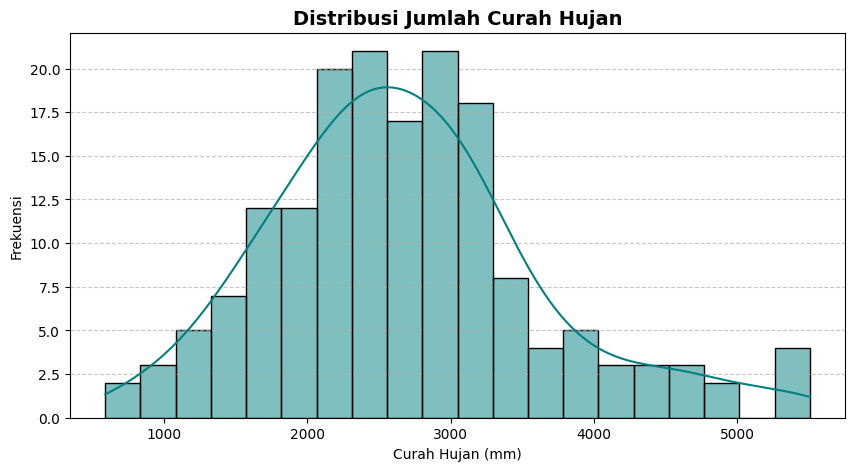

In [25]:
# 1. Ubah koma menjadi titik dan ubah tipe data menjadi float (angka)
col_name = 'Jumlah Curah Hujan Number of Precipitation (mm)'

# Cek jika kolom masih bertipe object/string, ubah koma ke titik lalu konversi ke numerik
if df[col_name].dtype == 'object':
    df[col_name] = df[col_name].astype(str).str.replace(',', '.', regex=False)
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# 2. Jalankan ulang visualisasi univariat (Histogram + KDE)
plt.figure(figsize=(10, 5))
sns.histplot(df[col_name], kde=True, color='teal', bins=20)
plt.title('Distribusi Jumlah Curah Hujan', fontsize=14, fontweight='bold')
plt.xlabel('Curah Hujan (mm)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Analisis Bivariat (Hubungan Antar Dua Variabel)

In [26]:
# Cek semua nama kolom yang ada di DataFrame Anda saat ini
print("Daftar kolom yang tersedia:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Daftar kolom yang tersedia:
0: Provinsi Province
1: Tahun
2: Jumlah Curah Hujan Number of Precipitation (mm)
3: Jumlah Hari Hujan (hari) Number of Rainy Days (day)2


Kolom Hari Hujan yang digunakan: Jumlah Hari Hujan (hari) Number of Rainy Days (day)2
Kolom Curah Hujan yang digunakan: Jumlah Curah Hujan Number of Precipitation (mm)


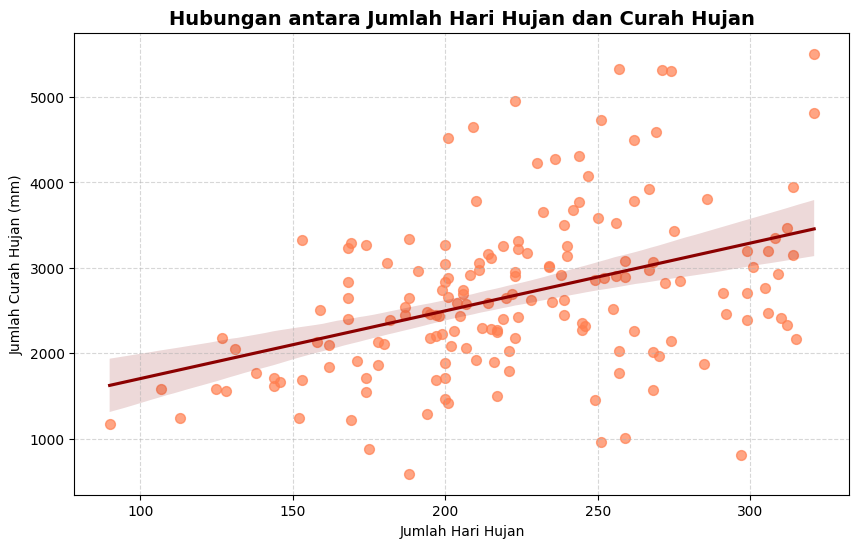

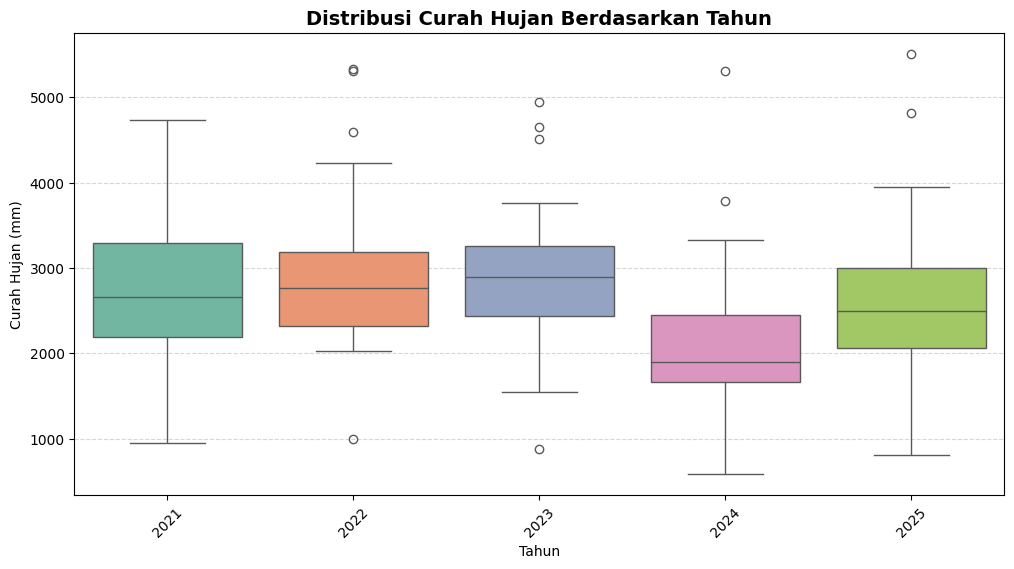

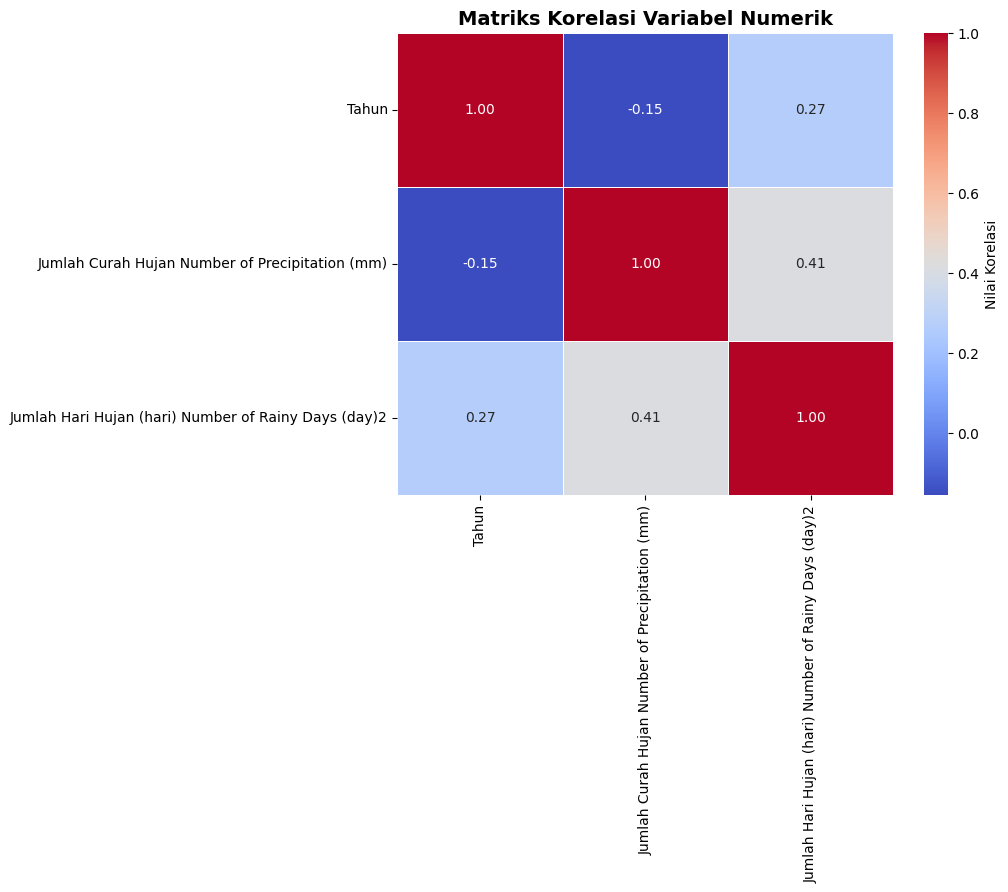

In [27]:
# Gunakan indeks kolom atau cari otomatis berdasarkan kata kunci
# Misal mencari kolom yang mengandung kata 'Hari' dan 'Hujan'
col_hari = [col for col in df.columns if 'Hari Hujan' in col][0]
col_hujan = [col for col in df.columns if 'Curah Hujan' in col][0]

print(f"Kolom Hari Hujan yang digunakan: {col_hari}")
print(f"Kolom Curah Hujan yang digunakan: {col_hujan}")

# Pastikan kedua kolom sudah bertipe numerik (bersih dari koma)
for col in [col_hari, col_hujan]:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# A. Scatter Plot + Garis Regresi
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x=col_hari,
    y=col_hujan,
    color='coral',
    scatter_kws={'alpha': 0.7, 's': 50},
    line_kws={'color': 'darkred'}
)
plt.title('Hubungan antara Jumlah Hari Hujan dan Curah Hujan', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Hari Hujan')
plt.ylabel('Jumlah Curah Hujan (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# B. Boxplot: Distribusi Curah Hujan berdasarkan Tahun
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Tahun', y=col_hujan, palette='Set2')
plt.title('Distribusi Curah Hujan Berdasarkan Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Curah Hujan (mm)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# C. Heatmap Korelasi Antar Variabel Numerik
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Nilai Korelasi'})
plt.title('Matriks Korelasi Variabel Numerik', fontsize=14, fontweight='bold')
plt.show()

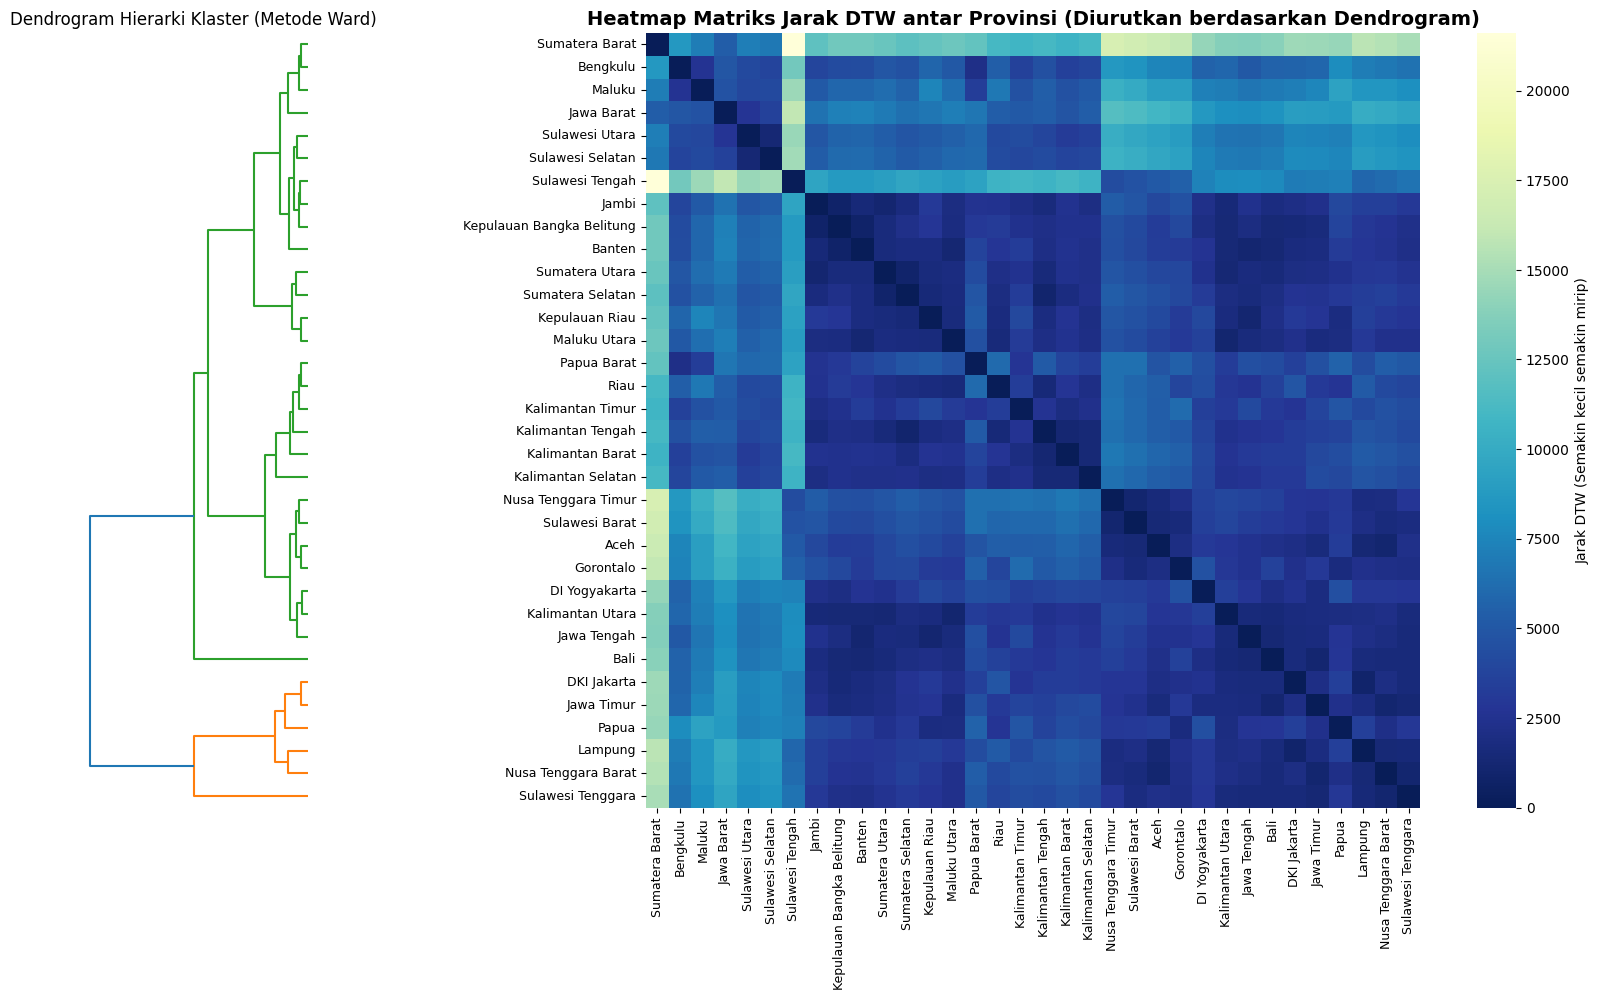

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Hitung Hierarchical Clustering (Linkage) pada matriks jarak DTW
# Menggunakan metode 'ward' untuk meminimalkan varians di dalam klaster
linkage_matrix = linkage(dtw_matrix, method='ward')

# 2. Buat subplot untuk dendrogram di kiri dan heatmap di kanan
fig = plt.figure(figsize=(16, 10))

# Atur rasio ukuran subplot (kiri untuk dendrogram, kanan untuk heatmap)
gs = plt.GridSpec(1, 2, width_ratios=[1, 5])

# Plot Dendrogram di sisi kiri
ax1 = fig.add_subplot(gs[0])
dendro = dendrogram(
    linkage_matrix,
    labels=valid_provinsi,  # Nama provinsi pada label daun dendrogram
    orientation='left',     # Orientasi horizontal agar nama provinsi terbaca
    leaf_font_size=10
)
ax1.set_title('Dendrogram Hierarki Klaster (Metode Ward)', fontsize=12)
ax1.axis('off') # Hilangkan sumbu koordinat pada dendrogram

# Plot Heatmap Matriks Jarak DTW di sisi kanan
ax2 = fig.add_subplot(gs[1])

# Mengambil urutan provinsi berdasarkan hasil dendrogram untuk menyusun heatmap
ordered_prov_indices = dendro['leaves']
ordered_provinsi = [valid_provinsi[i] for i in ordered_prov_indices]

# Buat matriks jarak yang sudah diurutkan sesuai dendrogram
ordered_dtw_matrix = dtw_matrix[ordered_prov_indices, :][:, ordered_prov_indices]

# Tampilkan heatmap
sns.heatmap(
    ordered_dtw_matrix,
    xticklabels=ordered_provinsi,
    yticklabels=ordered_provinsi,
    cmap='YlGnBu_r',   # Palet warna (Biru tua = Jarak kecil = Sangat Mirip)
    annot=False,      # Matriks terlalu besar untuk angka, matikan anotasi
    square=True,      # Kotak-kotak persegi
    cbar_kws={'label': 'Jarak DTW (Semakin kecil semakin mirip)'}
)

ax2.set_title('Heatmap Matriks Jarak DTW antar Provinsi (Diurutkan berdasarkan Dendrogram)', fontsize=14, fontweight='bold')
ax2.set_xticklabels(ordered_provinsi, rotation=90, fontsize=9)
ax2.set_yticklabels(ordered_provinsi, rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
!pip install fastdtw

Hasil Perbandingan DTW antara Aceh dan Sumatera Utara:
Jarak DTW (Semakin kecil, semakin mirip polanya): 3934.40


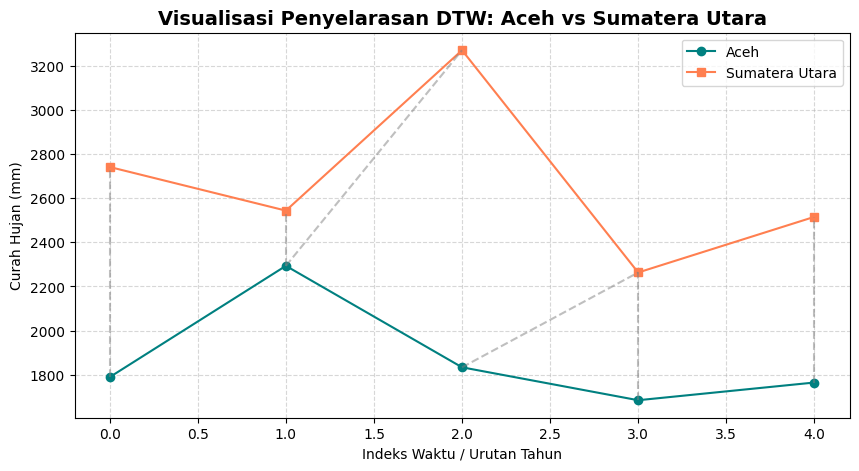

In [30]:
# Memastikan pengambilan data benar-benar menghasilkan array 1-D bersih
series1 = np.array([float(x) for x in df[df[col_provinsi] == prov_1][col_hujan].dropna()])
series2 = np.array([float(x) for x in df[df[col_provinsi] == prov_2][col_hujan].dropna()])

# Menghitung jarak dan path DTW dengan fungsi jarak manual (mengatasi error scipy vector validation)
dtw_distance, path = fastdtw(series1, series2, dist=lambda x, y: float(abs(x - y)))

print(f"Hasil Perbandingan DTW antara {prov_1} dan {prov_2}:")
print(f"Jarak DTW (Semakin kecil, semakin mirip polanya): {dtw_distance:.2f}")

# Visualisasi Penyelarasan DTW
plt.figure(figsize=(10, 5))
plt.plot(series1, label=f'{prov_1}', marker='o', color='teal')
plt.plot(series2, label=f'{prov_2}', marker='s', color='coral')

for point1, point2 in path:
    plt.plot([point1, point2], [series1[point1], series2[point2]], color='gray', linestyle='--', alpha=0.5)

plt.title(f'Visualisasi Penyelarasan DTW: {prov_1} vs {prov_2}', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Waktu / Urutan Tahun')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Penerapan Dynamic Time Warping (DTW) & K-Medoids

In [31]:
!pip install scikit-learn-extra fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 8.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154570 sha256=0f2b7a5580b673561b2c5018215b7c917d955d0ab6e89f2c75cae6ad0fc5e155
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


Total provinsi yang akan diklasterisasi: 34
Matriks jarak DTW berhasil dihitung!

--- Hasil Klasterisasi K-Medoids berdasarkan DTW ---


,Provinsi,Klaster
0,Aceh,0
7,Lampung,0
14,Jawa Timur,0
28,Gorontalo,0
25,Sulawesi Tengah,0
27,Sulawesi Tenggara,0
18,Nusa Tenggara Timur,0
17,Nusa Tenggara Barat,0
29,Sulawesi Barat,0
33,Papua,0


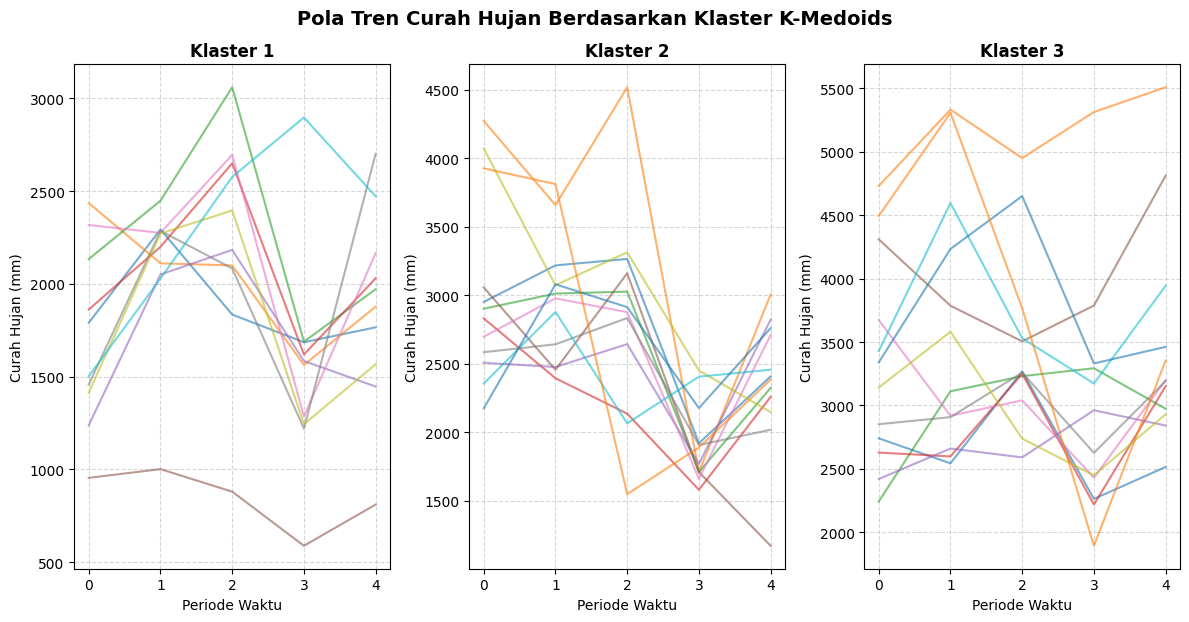

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
from sklearn_extra.cluster import KMedoids

# Pastikan nama kolom sudah sesuai
col_provinsi = 'Provinsi Province'
col_hujan = 'Jumlah Curah Hujan Number of Precipitation (mm)'

# 1. Mendapatkan daftar seluruh provinsi unik
daftar_provinsi = df[col_provinsi].unique()
n_provinsi = len(daftar_provinsi)

print(f"Total provinsi yang akan diklasterisasi: {n_provinsi}")

# 2. Menyiapkan dictionary untuk menyimpan data time series tiap provinsi
time_series_data = {}
for prov in daftar_provinsi:
    # Ambil data curah hujan bersih berbentuk array 1-D float
    ts = np.array([float(x) for x in df[df[col_provinsi] == prov][col_hujan].dropna()])
    if len(ts) > 0:
        time_series_data[prov] = ts

valid_provinsi = list(time_series_data.keys())
n_valid = len(valid_provinsi)

# 3. Membuat Matriks Jarak (Distance Matrix) menggunakan DTW antar semua provinsi
dtw_matrix = np.zeros((n_valid, n_valid))

for i in range(n_valid):
    for j in range(i, n_valid):
        series_i = time_series_data[valid_provinsi[i]]
        series_j = time_series_data[valid_provinsi[j]]

        # Hitung jarak DTW menggunakan fungsi jarak manual (mengatasi error scipy vector)
        distance, _ = fastdtw(series_i, series_j, dist=lambda x, y: float(abs(x - y)))

        dtw_matrix[i, j] = distance
        dtw_matrix[j, i] = distance  # Matriks simetris

print("Matriks jarak DTW berhasil dihitung!")

# 4. Menentukan Jumlah Klaster (K) - misalnya K = 3 klaster
k_clusters = 3

# Inisialisasi K-Medoids dengan metric='precomputed' karena kita menggunakan matriks jarak DTW
kmedoids = KMedoids(n_clusters=k_clusters, metric='precomputed', random_state=42)
kmedoids.fit(dtw_matrix)

# Mengambil hasil label klaster
labels = kmedoids.labels_

# 5. Menampilkan Hasil Klaster per Provinsi
hasil_klaster = pd.DataFrame({
    'Provinsi': valid_provinsi,
    'Klaster': kmedoids.labels_
})

print("\n--- Hasil Klasterisasi K-Medoids berdasarkan DTW ---")
display(hasil_klaster.sort_values(by='Klaster'))

# 6. Visualisasi Hasil Klaster (Plot Tren Curah Hujan per Klaster)
plt.figure(figsize=(12, 6))
for cluster_id in range(k_clusters):
    plt.subplot(1, k_clusters, cluster_id + 1)

    # Ambil provinsi yang masuk ke klaster ini
    prov_in_cluster = [valid_provinsi[i] for i in range(n_valid) if labels[i] == cluster_id]

    for prov in prov_in_cluster:
        plt.plot(time_series_data[prov], alpha=0.6, label=prov)

    plt.title(f'Klaster {cluster_id + 1}', fontsize=12, fontweight='bold')
    plt.xlabel('Periode Waktu')
    plt.ylabel('Curah Hujan (mm)')
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle('Pola Tren Curah Hujan Berdasarkan Klaster K-Medoids', y=1.03, fontsize=14, fontweight='bold')
plt.show()

#Visualisasi Pusat Klaster (Centroid/Medoid) DTW

--- Daftar Provinsi Pusat Klaster (Medoid) ---
Klaster 1: Nusa Tenggara Barat
Klaster 2: Kepulauan Bangka Belitung
Klaster 3: Kalimantan Tengah


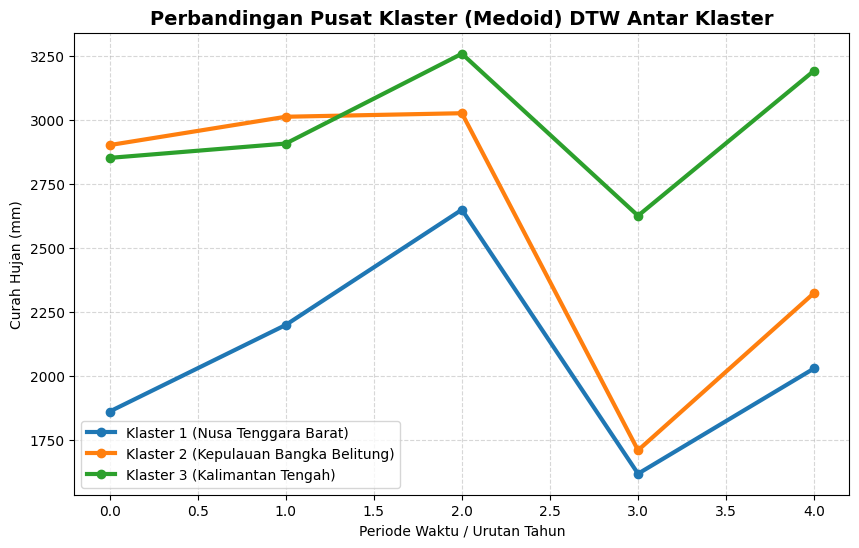

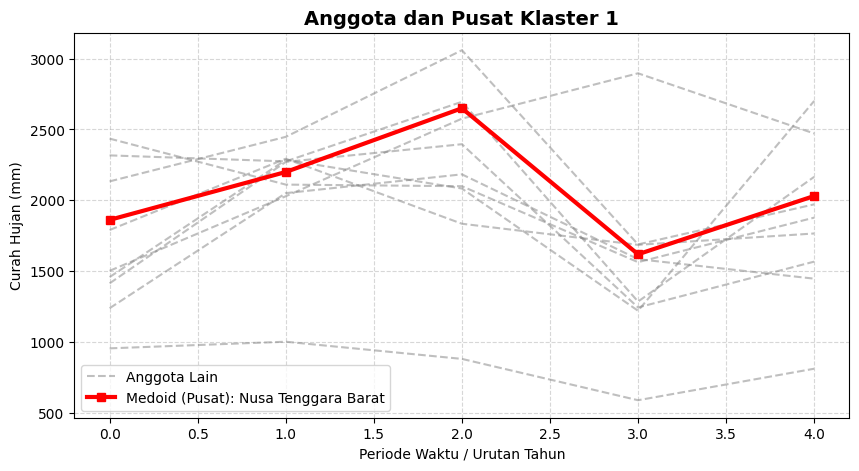

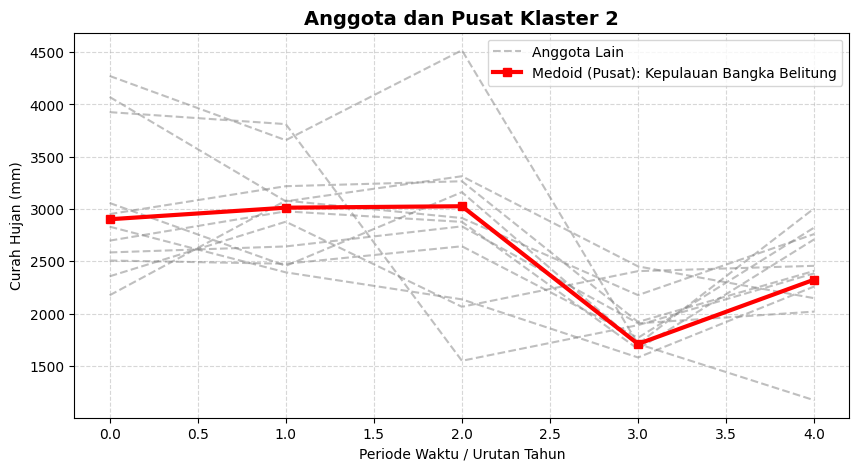

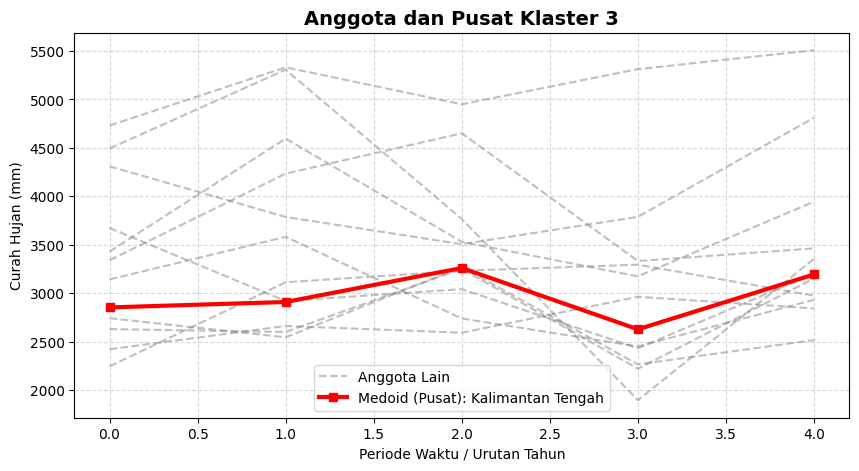

In [33]:
# 1. Mendapatkan indeks medoid dari hasil K-Medoids yang sudah dijalankan sebelumnya
medoid_indices = kmedoids.medoid_indices_

print("--- Daftar Provinsi Pusat Klaster (Medoid) ---")
for cluster_id, medoid_idx in enumerate(medoid_indices):
    medoid_prov = valid_provinsi[medoid_idx]
    print(f"Klaster {cluster_id + 1}: {medoid_prov}")

# 2. Visualisasi Perbandingan Semua Medoid dalam Satu Grafik Utama
plt.figure(figsize=(10, 6))

for cluster_id, medoid_idx in enumerate(medoid_indices):
    medoid_prov = valid_provinsi[medoid_idx]
    medoid_series = time_series_data[medoid_prov]

    # Plot garis medoid dengan garis lebih tebal dan penanda
    plt.plot(medoid_series, marker='o', linewidth=3, label=f'Klaster {cluster_id + 1} ({medoid_prov})')

plt.title('Perbandingan Pusat Klaster (Medoid) DTW Antar Klaster', fontsize=14, fontweight='bold')
plt.xlabel('Periode Waktu / Urutan Tahun')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Visualisasi Detail: Anggota Klaster dibandingkan dengan Medoid-nya
for cluster_id, medoid_idx in enumerate(medoid_indices):
    medoid_prov = valid_provinsi[medoid_idx]

    plt.figure(figsize=(10, 5))

    # Ambil semua provinsi yang tergabung dalam klaster ini
    prov_in_cluster = [valid_provinsi[i] for i in range(n_valid) if labels[i] == cluster_id]

    # Plot seluruh anggota klaster dengan warna abu-abu transparan
    for prov in prov_in_cluster:
        if prov == medoid_prov:
            continue
        plt.plot(time_series_data[prov], color='gray', alpha=0.5, linestyle='--', label='Anggota Lain' if prov == prov_in_cluster[0] else "")

    # Plot provinsi medoid dengan warna merah tebal agar mencolok sebagai pusat
    plt.plot(time_series_data[medoid_prov], color='red', marker='s', linewidth=3, label=f'Medoid (Pusat): {medoid_prov}')

    plt.title(f'Anggota dan Pusat Klaster {cluster_id + 1}', fontsize=14, fontweight='bold')
    plt.xlabel('Periode Waktu / Urutan Tahun')
    plt.ylabel('Curah Hujan (mm)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

#VISUALISASI PETA

In [34]:
!pip install geopandas

=== KLASTER 1 (Total: 10 Provinsi) ===
Aceh, Lampung, Jawa Timur, Nusa Tenggara Barat, Nusa Tenggara Timur, Sulawesi Tengah, Sulawesi Tenggara, Gorontalo, Sulawesi Barat, Papua
--------------------------------------------------
=== KLASTER 2 (Total: 12 Provinsi) ===
Jambi, Bengkulu, Kepulauan Bangka Belitung, DKI Jakarta, Jawa Tengah, DI Yogyakarta, Banten, Bali, Kalimantan Timur, Kalimantan Utara, Maluku Utara, Papua Barat
--------------------------------------------------
=== KLASTER 3 (Total: 12 Provinsi) ===
Sumatera Utara, Sumatera Barat, Riau, Sumatera Selatan, Kepulauan Riau, Jawa Barat, Kalimantan Barat, Kalimantan Tengah, Kalimantan Selatan, Sulawesi Utara, Sulawesi Selatan, Maluku
--------------------------------------------------


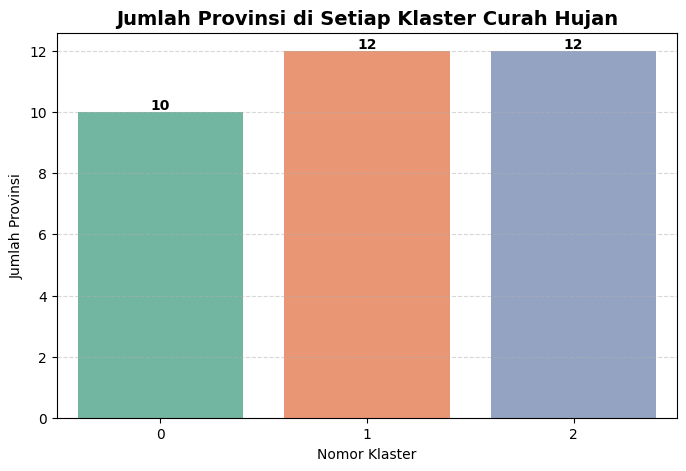

In [39]:
# Menampilkan daftar provinsi yang tergabung di setiap klaster secara rinci
for cluster_id in range(k_clusters):
    prov_in_cluster = hasil_klaster[hasil_klaster['Klaster'] == cluster_id]['Provinsi'].tolist()
    print(f"=== KLASTER {cluster_id + 1} (Total: {len(prov_in_cluster)} Provinsi) ===")
    print(", ".join(prov_in_cluster))
    print("-" * 50)

# Visualisasi Bar Chart: Jumlah Provinsi per Klaster
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=hasil_klaster, x='Klaster', palette='Set2')
plt.title('Jumlah Provinsi di Setiap Klaster Curah Hujan', fontsize=14, fontweight='bold')
plt.xlabel('Nomor Klaster')
plt.ylabel('Jumlah Provinsi')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontweight='bold')

plt.show()

Kolom properti peta: Index(['id', 'KODE_PROV', 'PROVINSI', 'geometry'], dtype='object')


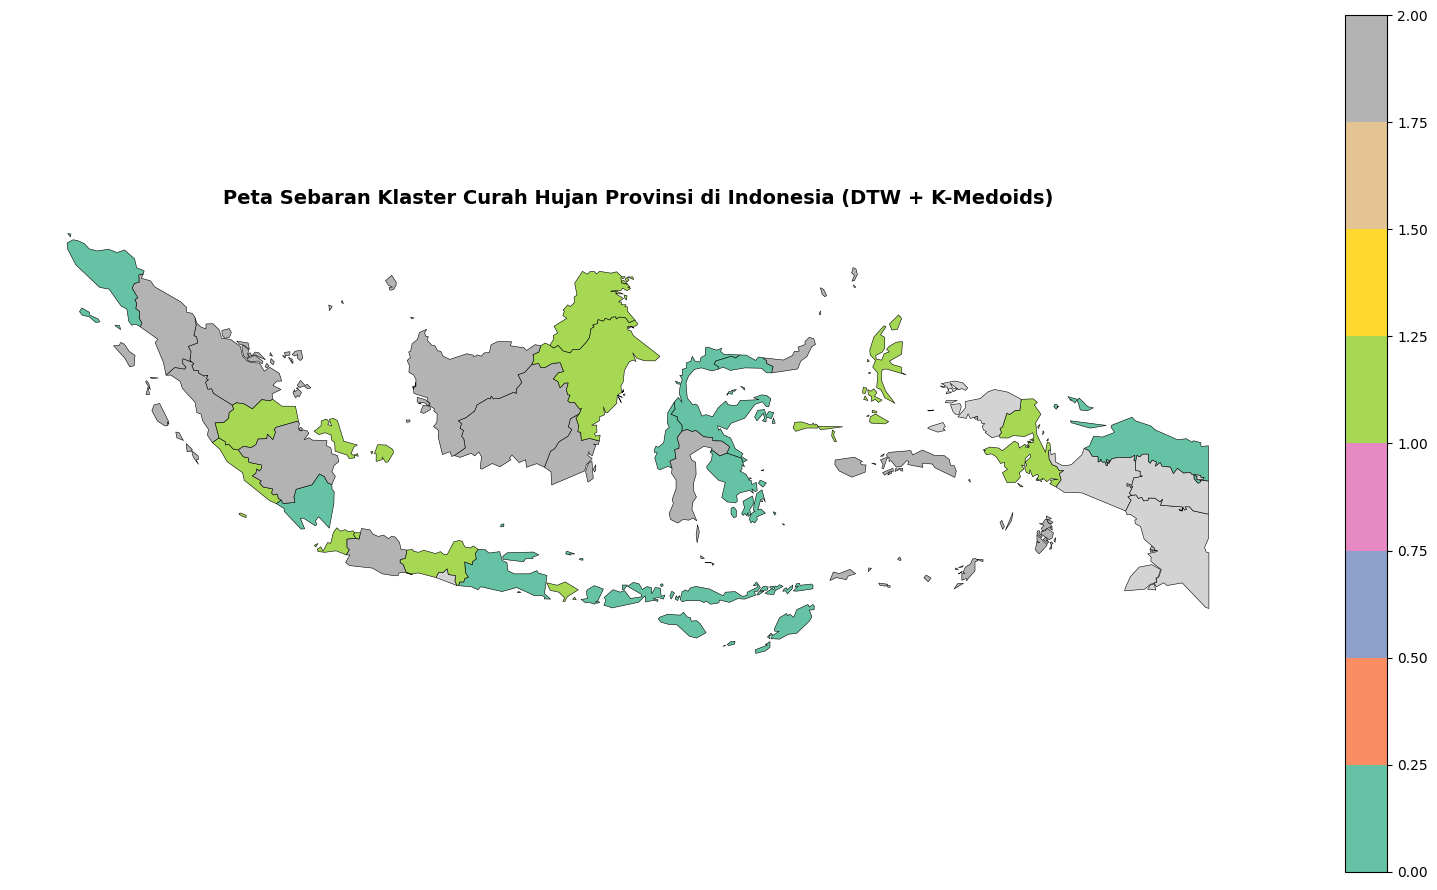

In [40]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Menggunakan link GeoJSON resmi Indonesia dengan 38 provinsi yang aktif dan stabil
url_geojson = "https://raw.githubusercontent.com/denyherianto/indonesia-geojson-topojson-maps-with-38-provinces/main/GeoJSON/indonesia-38-provinces.geojson"

# Memuat data peta
gdf_indo = gpd.read_file(url_geojson)

# Cek nama kolom properti wilayah pada peta (biasanya 'PROVINSI')
print("Kolom properti peta:", gdf_indo.columns)

# 2. Menyelaraskan nama provinsi agar seragam (huruf kapital)
gdf_indo['PROVINSI_Clean'] = gdf_indo['PROVINSI'].str.upper().str.strip()
hasil_klaster['Provinsi_Clean'] = hasil_klaster['Provinsi'].str.upper().str.strip()

# Melakukan merge (penggabungan) data peta dengan hasil klaster
peta_klaster = gdf_indo.merge(
    hasil_klaster,
    left_on='PROVINSI_Clean',
    right_on='Provinsi_Clean',
    how='left'
)

# 3. Visualisasi Peta Klaster Indonesia
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

peta_klaster.plot(
    column='Klaster',
    ax=ax,
    legend=True,
    cmap='Set2',              # Palet warna klaster
    missing_kwds={
        "color": "lightgrey",
        "label": "Tidak ada data / Di luar cakupan"
    },
    edgecolor='black',
    linewidth=0.4
)

plt.title('Peta Sebaran Klaster Curah Hujan Provinsi di Indonesia (DTW + K-Medoids)', fontsize=14, fontweight='bold')
plt.axis('off')  # Menghilangkan garis koordinat
plt.tight_layout()
plt.show()

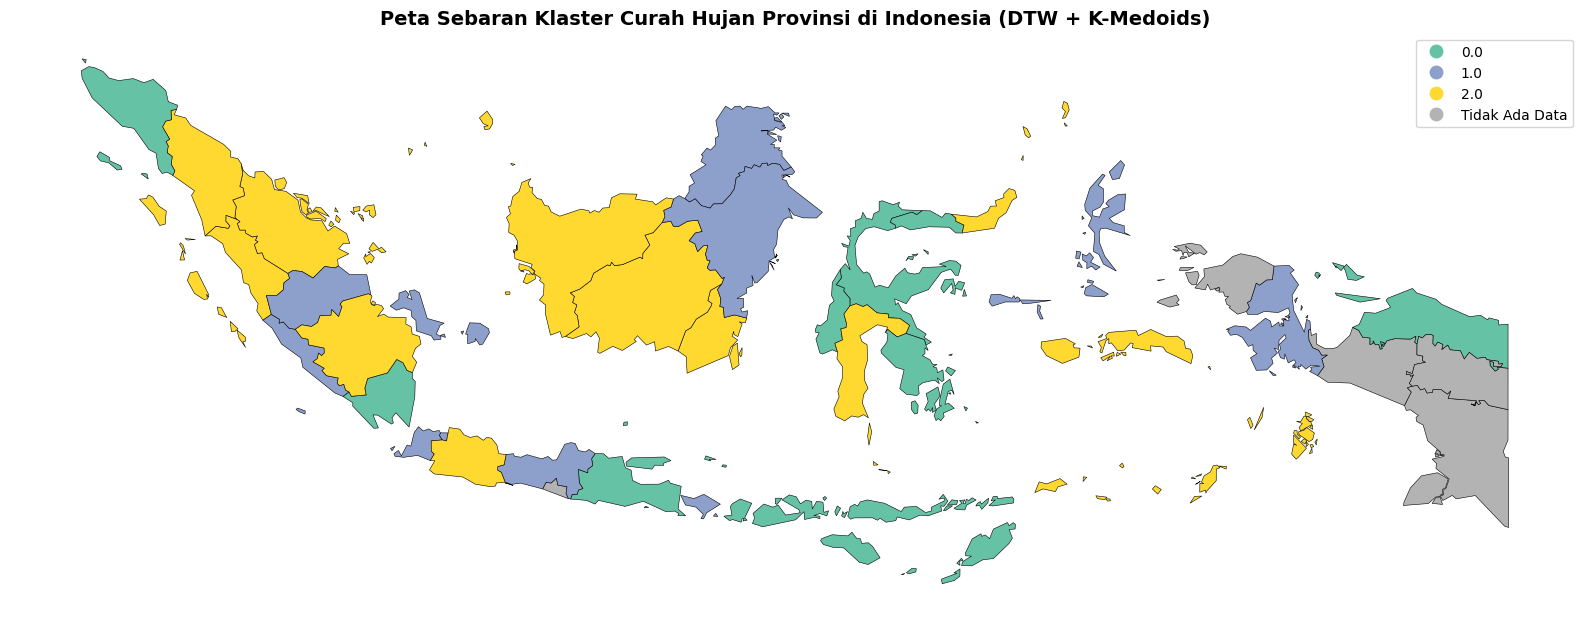

In [41]:
# Memastikan kolom klaster bertipe kategori atau string agar plotnya diskrit (bukan kontinu)
peta_klaster['Klaster_Str'] = peta_klaster['Klaster'].astype(str).replace('nan', 'Tidak Ada Data')

fig, ax = plt.subplots(1, 1, figsize=(16, 9))

peta_klaster.plot(
    column='Klaster_Str',
    ax=ax,
    legend=True,
    cmap='Set2',
    edgecolor='black',
    linewidth=0.4
)

plt.title('Peta Sebaran Klaster Curah Hujan Provinsi di Indonesia (DTW + K-Medoids)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()